# AI in Practice: CNN Flower Classification

*Author: Valentina Staneva*

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/drive/1sJAnrbbFTzT1e2qTFK_2Kt2yTo5Qqnu8?usp=sharing)

This notebook demonstrates training a CNN model to classify flower images.

This notebook is built on these sources:

* [*Tensorflow Classification Tutorial*](https://www.tensorflow.org/tutorials/images/classification)


The notebook goes through the following workflow:
1. Read a dataset of flower images and prepare for training, validation, and testing
2. Train a basic dense model
3. Train a CNN model
4. Incorporate a data augmentation strategy
5. Test model performance on the held out dataset

## Setup

In [ ]:
import os
os.environ["KERAS_BACKEND"] = "torch"

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import PIL

import keras
from keras import layers
from keras.models import Sequential

In [ ]:
# set random seed for result reproducibility
keras.utils.set_random_seed(123)

## Flowers Dataset

This tutorial uses a [dataset](https://www.tensorflow.org/datasets/catalog/tf_flowers) of about 3,700 photos of flowers. The dataset contains five types of flowers:

```
  daisy
  dandelion
  roses
  sunflowers
  tulips
```

The goal is to build a classifier which predicts the type of flowers in new images.

The dataset is part of a collection of [datasets](https://www.tensorflow.org/datasets) in the `tensorflow` library which can be directly loaded.

In [ ]:
# downloading images

import pathlib
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"
data_dir = keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True)
data_dir = pathlib.Path(data_dir).with_suffix('')
print(data_dir)

image_count = len(list(data_dir.glob('*/*.jpg')))
print(image_count)

/root/.keras/datasets/flower_photos_extracted
0


In [ ]:
ls /root/.keras/datasets/flower_photos_extracted/flower_photos

daisy/  dandelion/  LICENSE.txt  roses/  sunflowers/  tulips/


We note that the images are arranged in folders with their names.

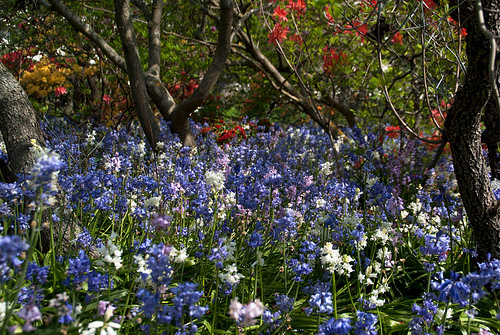

In [ ]:
# looking at a few tulips
tulips = list(sorted(data_dir.glob('flower_photos/tulips/*')))
PIL.Image.open(str(tulips[1]))

*Images are not the same size!*

The images in the dataset are not the same size so we will resize them so that it is easier to put them in an array and process them efficiently. We fix the weight and height to be 150 (this will distort the images a bit but we want to see if the algorithm can be robust to some stretching). Resizing can be achieved automatically while reading the data with the `keras.utils.image_dataset_from_directory` function and setting the image size. This function can do a few extra steps for us:

* split the data into two subsets: training and testing
* infer the labels come from the name of the folders and put them in categorical format


In [ ]:
HEIGHT = 150
WIDTH = 150

In [ ]:
train_ds, test_ds = keras.utils.image_dataset_from_directory(
  data_dir / "flower_photos",
  validation_split=0.2,
  subset="both",
  labels="inferred",
  label_mode="categorical",
  seed=123,
  image_size=(HEIGHT, WIDTH),
)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Using 734 files for validation.


📝 **Note:** If resizing images in your dataset, you need to select an approach which does not distort substantially your data. The `keras.utils.image_dataset_from_directory` function has some other options such as cropping or padding to aspect ratio. In your research, you may need write your own functions which are appropriate for your data.





In [ ]:
help(keras.utils.image_dataset_from_directory)

Help on function image_dataset_from_directory in module keras.src.utils.image_dataset_utils:

image_dataset_from_directory(directory, labels='inferred', label_mode='int', class_names=None, color_mode='rgb', batch_size=32, image_size=(256, 256), shuffle=True, seed=None, validation_split=None, subset=None, interpolation='bilinear', follow_links=False, crop_to_aspect_ratio=False, pad_to_aspect_ratio=False, data_format=None, format='tf', verbose=True)
    Generates a dataset from image files in a directory.

    If your directory structure is:

    ```
    main_directory/
    ...class_a/
    ......a_image_1.jpg
    ......a_image_2.jpg
    ...class_b/
    ......b_image_1.jpg
    ......b_image_2.jpg
    ```

    Then calling `image_dataset_from_directory(main_directory,
    labels='inferred')` will return a dataset that yields batches of
    images from the subdirectories `class_a` and `class_b`, together with labels
    0 and 1 (0 corresponding to `class_a` and 1 corresponding to `class_b`)

### Held-out test set
Note we set aside 20% for a test set which we will NOT use in model training and selection. It is easy to overfit the model performance to the specific test we have selected and because we have no more "unseen" data to test on, our measures of performance may be skewed. We will only use the test set in the end to evaluate the performance on "unseen" data.

📝 **Note:**
 While the loading function called the split "validation", the way we are treating it determines its name: if we are only using it in the end, and we do not have any other flower data to test on, then it is a "test" set, while if we are using it for experimentation, then it is a "validations" set. Occasionally, you will find this terminology reversed, but we will stick to these definitions here.

⚠️ **Warning:** When splitting a dataset, we should also be careful how our data are ordered. By default, this function is shuffling the data before splitting, so we will not get only one type of flowers in the test set. In practice, you may want to design your own validation strategy, and you may need to define your own splitting functions, but this will give you full control over your experiments.

The output data format is organized in batches which is good for efficiency, but since this dataset is not big and we want to simplify the structure we will convert it to `numpy` arrays.

In [ ]:
list(train_ds.unbatch())[1][1]

<tf.Tensor: shape=(5,), dtype=float32, numpy=array([0., 0., 0., 1., 0.], dtype=float32)>

In [ ]:
# convert to numpy arrays
train_images, train_labels = zip(*list(train_ds.unbatch()))
train_images = np.array(train_images)
train_labels = np.array(train_labels)

In [ ]:
print(train_images.shape)
print(train_labels.shape)

(2936, 150, 150, 3)
(2936, 5)


We loaded the labels in a categorical format, but we also need the class names. These correspond to the directory names in alphabetical order.

In [ ]:
class_names = ["daisy", "dandelion", "roses", "sunflowers","tulips"]
num_classes = len(class_names)

Let's see the distribution of the classes:

<BarContainer object of 5 artists>

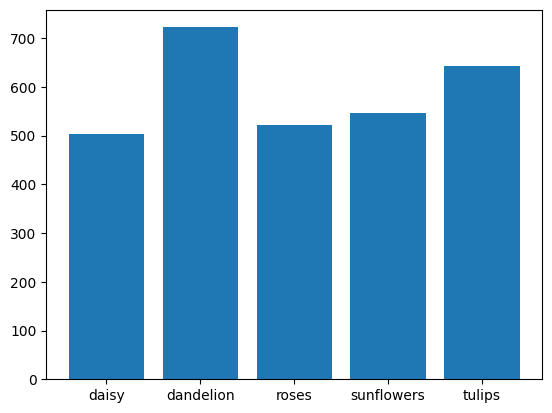

In [ ]:
plt.bar(class_names, train_labels.sum(axis=0))

### Visualize the data



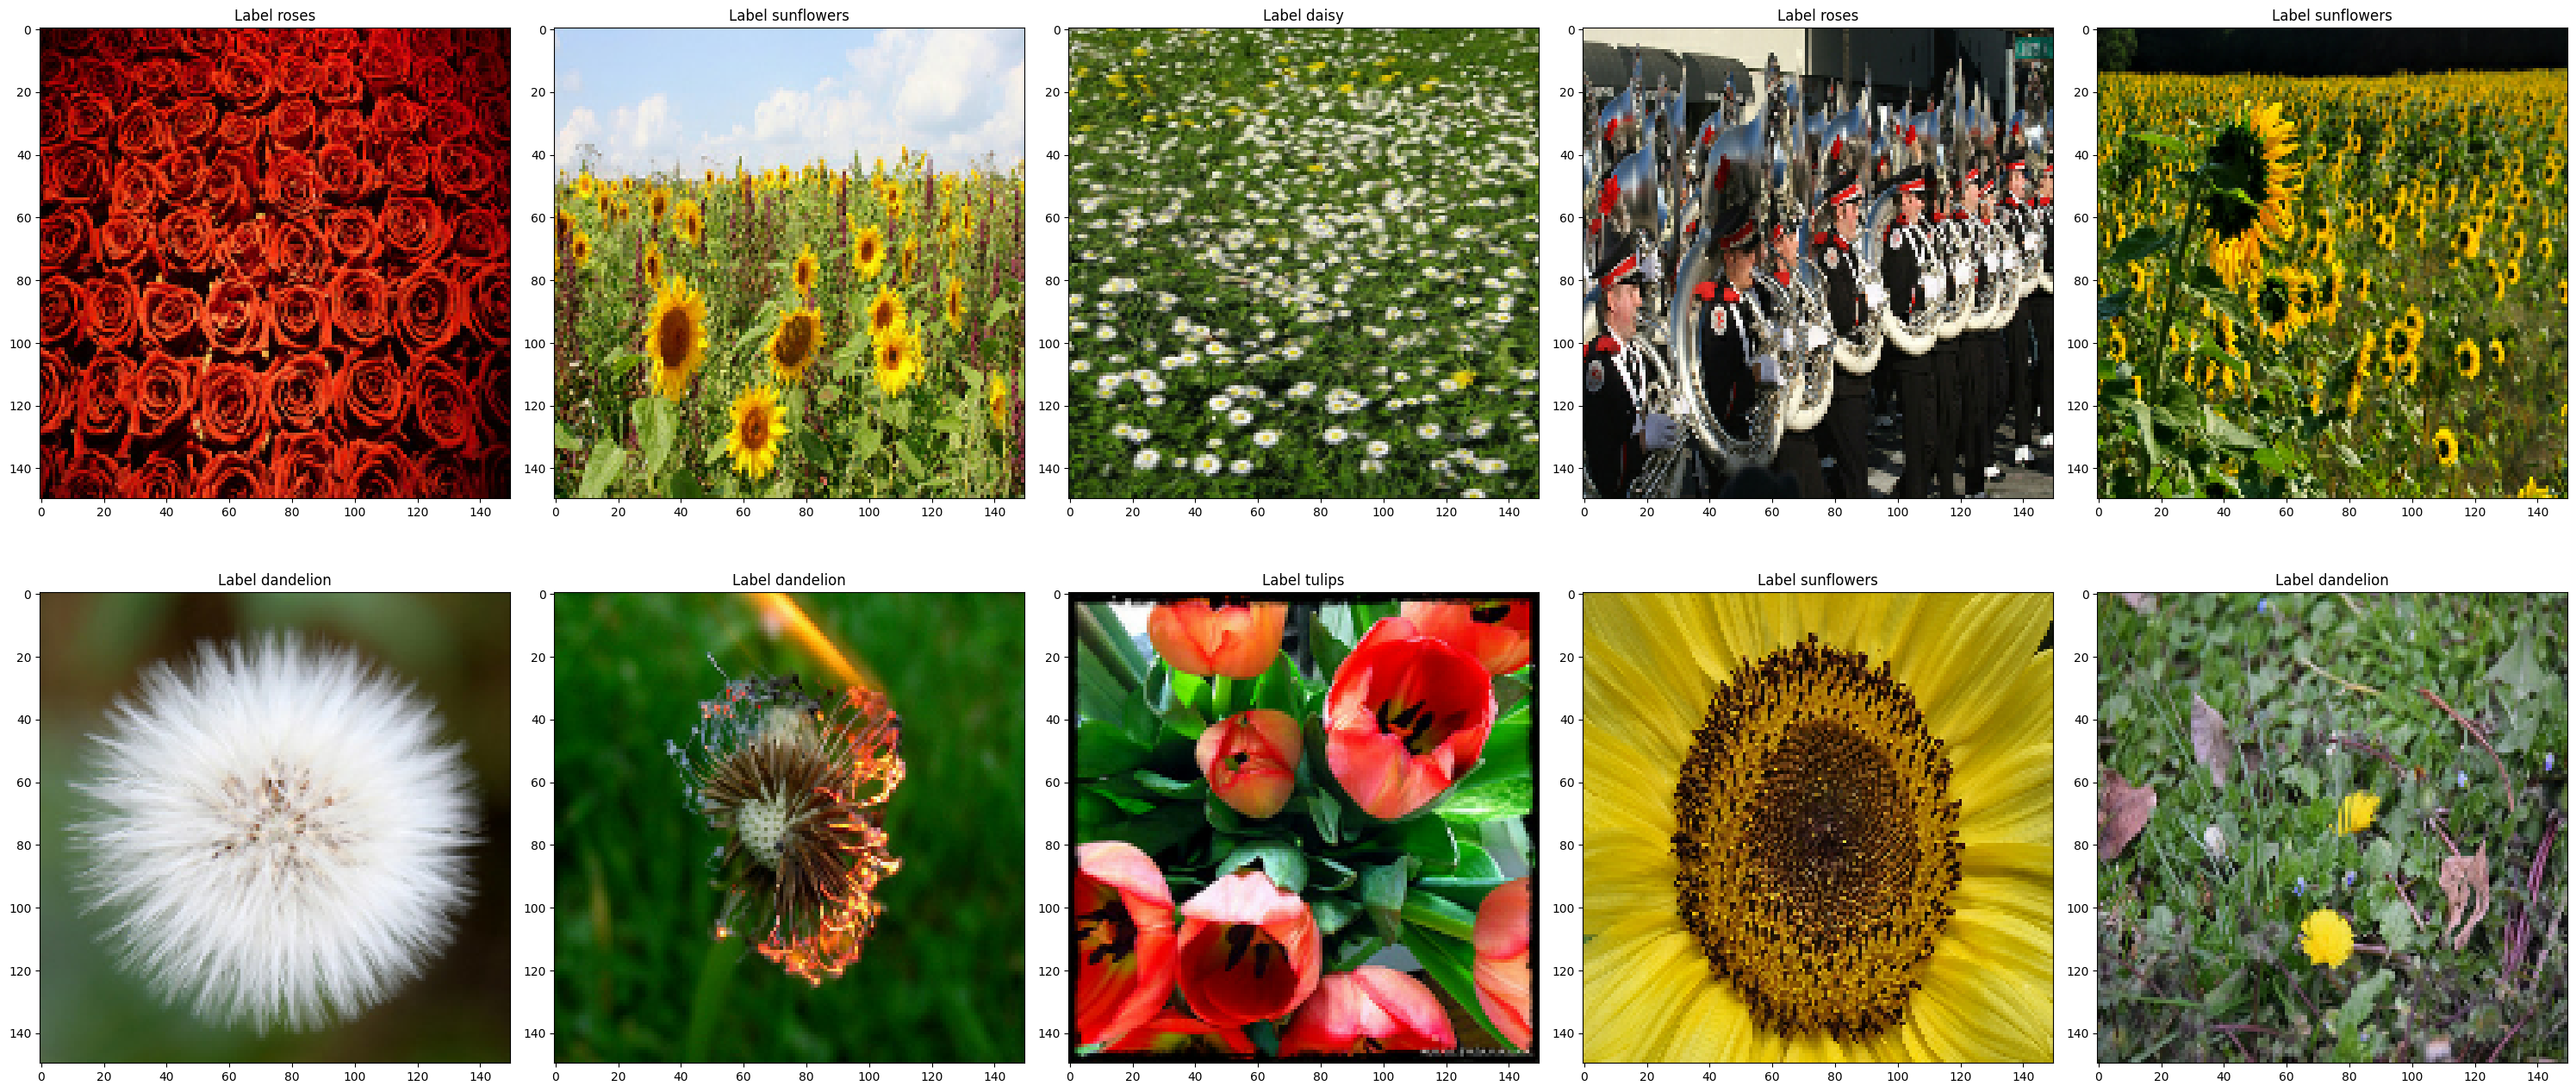

In [ ]:
plt.rcParams["figure.figsize"] = [30, 15]
plt.rcParams["figure.autolayout"] = True

counter = 0
for image, label in zip(train_images, train_labels):
  plt.subplot(2, 5, counter+1)
  plt.imshow(image.astype("uint8"))
  label_name = class_names[np.where(label==1)[0][0]]
  plt.title('Label {}'.format(label_name))
  counter += 1
  if counter == 10:
    break

### Rescale the data

The RGB channel values are in the `[0, 255]` range. This is not ideal for a neural network; in general you should seek to make your input values small.

We can rescale values to be in the `[0, 1]` range by using `tf.keras.layers.Rescaling` in the model definition itself.

In [ ]:
layers.Rescaling(1./255)

<Rescaling name=rescaling, built=False>

## Dense Model

In [ ]:
from keras.layers import Input, Dense, Flatten, Rescaling, Conv2D, MaxPooling2D

In [ ]:
# Define a dense neural network with one hidden layer
output_dim = train_labels.shape[1]
hidden_dim = 50

dense_model = keras.Sequential()
dense_model.add(Input(shape = (HEIGHT, WIDTH, 3)))
dense_model.add(Flatten())
dense_model.add(Rescaling(1./255))
dense_model.add(Dense(hidden_dim, activation="relu"))
dense_model.add(Dense(output_dim, activation="softmax"))

In [ ]:
dense_model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ flatten (Flatten)               │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ rescaling_1 (Rescaling)         │ (None, 67500)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 50)             │     3,375,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           255 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,375,305 (12.88 MB)

 Trainable params: 3,375,305 (12.88 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Define the loss and the evaluation metrics
dense_model.compile(optimizer=keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', patience=5,  restore_best_weights=True)

In [ ]:
# Fit the model
history = dense_model.fit(train_images,
                          train_labels,
                          validation_split=0.2,
                          epochs=50,
                          batch_size=32,
                          callbacks=[es]
                          )

Epoch 1/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 3s 16ms/step - accuracy: 0.3228 - loss: 1.5930 - val_accuracy: 0.3912 - val_loss: 1.4189
Epoch 2/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.4434 - loss: 1.3427 - val_accuracy: 0.4031 - val_loss: 1.4268
Epoch 3/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5072 - loss: 1.2198 - val_accuracy: 0.4099 - val_loss: 1.4025
Epoch 4/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5311 - loss: 1.1551 - val_accuracy: 0.4218 - val_loss: 1.3369
Epoch 5/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5686 - loss: 1.1018 - val_accuracy: 0.4456 - val_loss: 1.3222
Epoch 6/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.5745 - loss: 1.0944 - val_accuracy: 0.4082 - val_loss: 1.4156
Epoch 7/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 1s 19ms/step - accuracy: 0.5703 - loss: 1.0644 - val_accuracy: 0.4371 - val_loss: 1.3762
Epoch 8/50
74/74 ━━━━━━━━━━━━━━━━━━━━ 2s 20ms/step - accuracy: 0.5975 - loss: 1.0205 - val_accuracy: 0.4354 - v

In [ ]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True

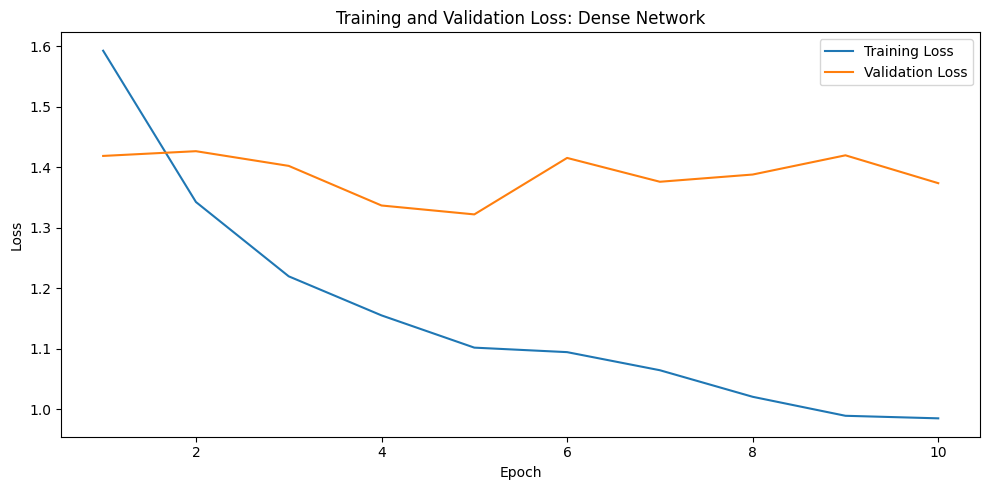

Text(0, 0.5, 'Accuracy')

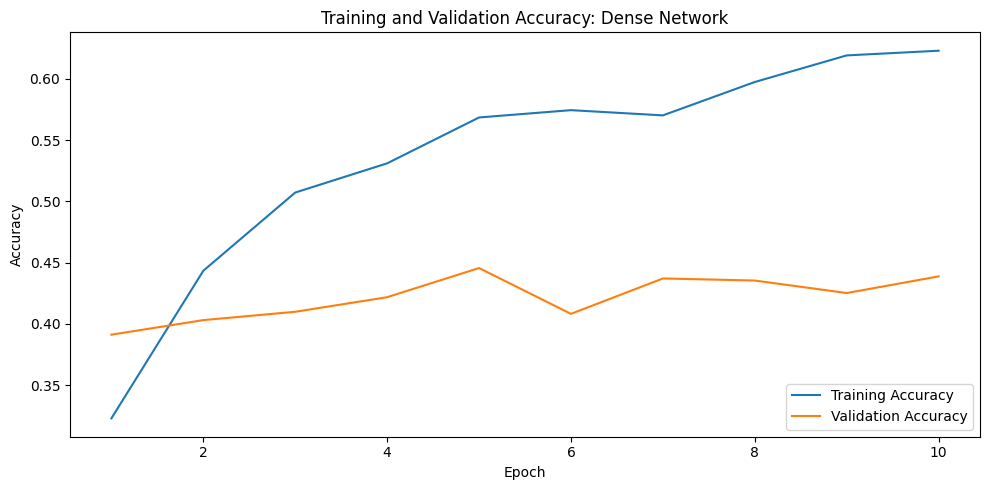

In [ ]:
# accuracy metrics at each iteration are stored in the history variable
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(history.history['loss'])+1)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Dense Network')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Dense Network')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

Performance is not very good! Since flowers in the images are not centered, it is hard for a dense linear network to learn how to match the color in one image to the corresponding color in another image. Since there are way more parameters that observation the network can overfit on the training data but cannot predict on the validation data.

## CNN Model



### Create the model

The Keras [Sequential](https://www.tensorflow.org/guide/keras/sequential_model) model consists of three convolution blocks (`keras.layers.Conv2D`) with a max pooling layer (`keras.layers.MaxPooling2D`) in each of them. There's a fully-connected layer (`keras.layers.Dense`) with 128 units on top of it that is activated by a ReLU activation function (`'relu'`). This model has not been tuned for high accuracy; the goal of this tutorial is to show a standard approach.

In [ ]:
cnn_model = Sequential([
  layers.Input(shape = (HEIGHT, WIDTH, 3)),
  layers.Rescaling(1./255),

  layers.Conv2D(filters=16, kernel_size=3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(filters=64, kernel_size=3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(filters=128, kernel_size=3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),

  layers.Dense(num_classes, name="outputs", activation='softmax')
])

View all the layers of the network using the Keras `Model.summary` method:

In [ ]:
cnn_model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)         │ (None, 150, 150, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 150, 150, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 75, 75, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 75, 75, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 37, 37, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 37, 37, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 18, 18, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 18, 18, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 9, 9, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 10368)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     1,327,232 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ outputs (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 1,425,317 (5.44 MB)

 Trainable params: 1,425,317 (5.44 MB)

 Non-trainable params: 0 (0.00 B)



For this tutorial, choose the `keras.optimizers.Adam` optimizer and `categorical_crossentropy` loss function. To view training and validation accuracy for each training epoch, pass the `metrics` argument to `Model.compile`.

In [ ]:
cnn_model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

One can pass other built-in metrics or pass their own metric function.

🧑‍💻 **Exercise:** Pass other [metrics](https://www.tensorflow.org/api_docs/python/tf/keras/metrics) and run the plot below. Modify the plots to visualize the other metrics.

### Train the model

**Early Stopping:** We set the max number of epochs to 50 in the `Model.fit` method, but we will also set an early stopping criterion which will monitor how the algorithm performs on the validation set, and if there is no significant improvement, the algorithm will stop.

In [ ]:
from keras.callbacks import EarlyStopping
es = EarlyStopping(monitor='val_loss', mode='min', patience=10,  restore_best_weights=True)

**Note:** We may want to select the algorithm with the maximum validation accuracy, however, the accuracy is a noisy metric, so monitoring the validation loss can be a bit more stable.

In [ ]:
train_labels.shape

(2936, 5)

In [ ]:
2936*0.8/64

36.7

In [ ]:
%%time
epochs=50
history = cnn_model.fit(
  train_images,
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=64,
  callbacks=[es]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 49ms/step - accuracy: 0.3164 - loss: 1.4934 - val_accuracy: 0.4643 - val_loss: 1.3611
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step - accuracy: 0.5315 - loss: 1.1760 - val_accuracy: 0.5000 - val_loss: 1.2148
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.5656 - loss: 1.0490 - val_accuracy: 0.5680 - val_loss: 1.0900
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 48ms/step - accuracy: 0.6286 - loss: 0.9384 - val_accuracy: 0.6071 - val_loss: 1.0333
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 54ms/step - accuracy: 0.6687 - loss: 0.8537 - val_accuracy: 0.6003 - val_loss: 1.0143
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7138 - loss: 0.7478 - val_accuracy: 0.6276 - val_loss: 0.9998
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7389 - loss: 0.6850 - val_accuracy: 0.6156 - val_loss: 1.0755
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 2s 46ms/step - accuracy: 0.7709 - loss: 0.5994 - val_accuracy: 0.6224 - v

⚠️ **Warning:** If you run the fit command twice the model will continue to update the existing model, unless you rerun the model definition command.

We observe that

* the training set accuracy is almost 1
* the validation set accuracy is around ~0.63.

### Visualize training results

Create plots of the loss and accuracy on the training and validation sets:

In [ ]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True

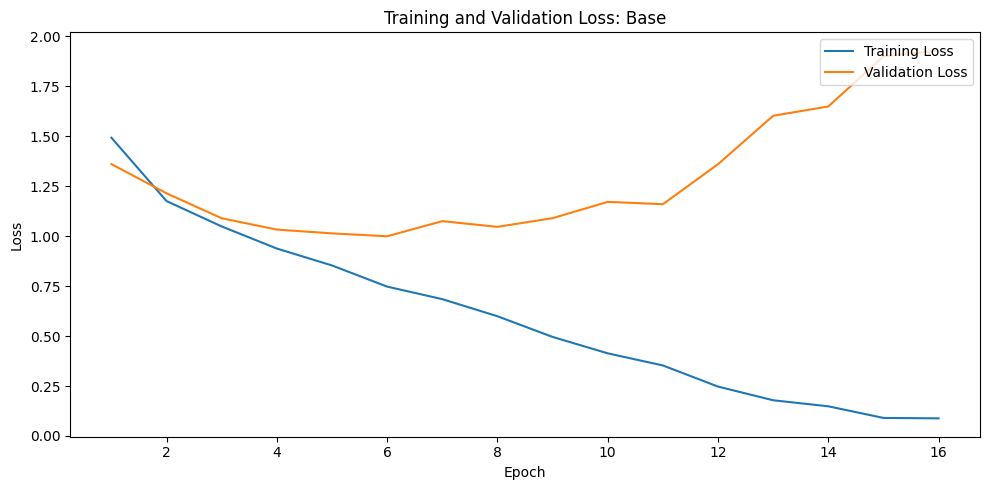

Text(0, 0.5, 'Accuracy')

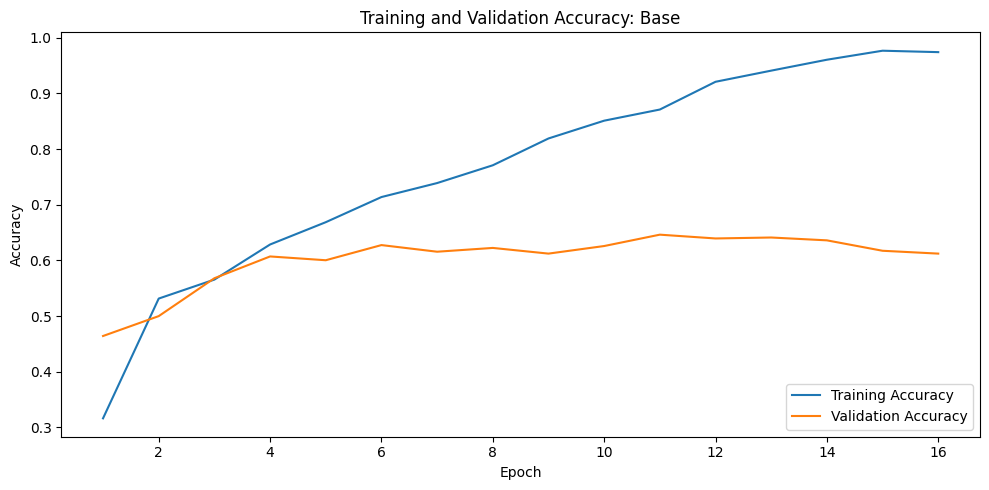

In [ ]:
# accuracy metrics at each iteration are stored in the history variable
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(history.history['loss'])+1)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Base')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Base')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

The plots show that training accuracy and validation accuracy are off by large margins, and the model has achieved around 60% accuracy on the validation set. Better than before, but still space for improvement.

The next two sections of the tutorial show some strategies how to avoid some of the overfitting challenges.

🧑‍💻 **Exercise:** Add one more 2D convolutional layer to the existing model. Retrain the model and visualize the performance. What do you observe? Name your model `deeper_cnn_model` so that you save it as a separate variable.

## Model Improvements

In the plots above, the training accuracy is increasing linearly over time, whereas validation accuracy stalls around 60% in the training process. Also, the difference in accuracy between training and validation accuracy is noticeable—a sign of [overfitting](https://www.tensorflow.org/tutorials/keras/overfit_and_underfit).

When there are a small number of training examples, the model sometimes learns from noises or unwanted details from training examples—to an extent that it negatively impacts the performance of the model on new examples. This phenomenon is known as overfitting. It means that the model will have a difficult time generalizing on a new dataset.

There are multiple ways to fight overfitting in the training process and we will discuss those below.

### Data Augmentation

Data augmentation takes the approach of generating additional training data from your existing examples by augmenting them using random transformations that yield believable-looking images. This helps expose the model to more aspects of the data and generalize better.

We will implement data augmentation using the following Keras preprocessing layers: `keras.layers.RandomFlip`, `keras.layers.RandomRotation`, and `keras.layers.RandomZoom`. These can be included inside your model like other layers, and run on the GPU.

Visualize a few augmented examples by applying data augmentation to the same image several times:

In [ ]:
data_augmentation = keras.Sequential(
  [
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1),
  ]
)

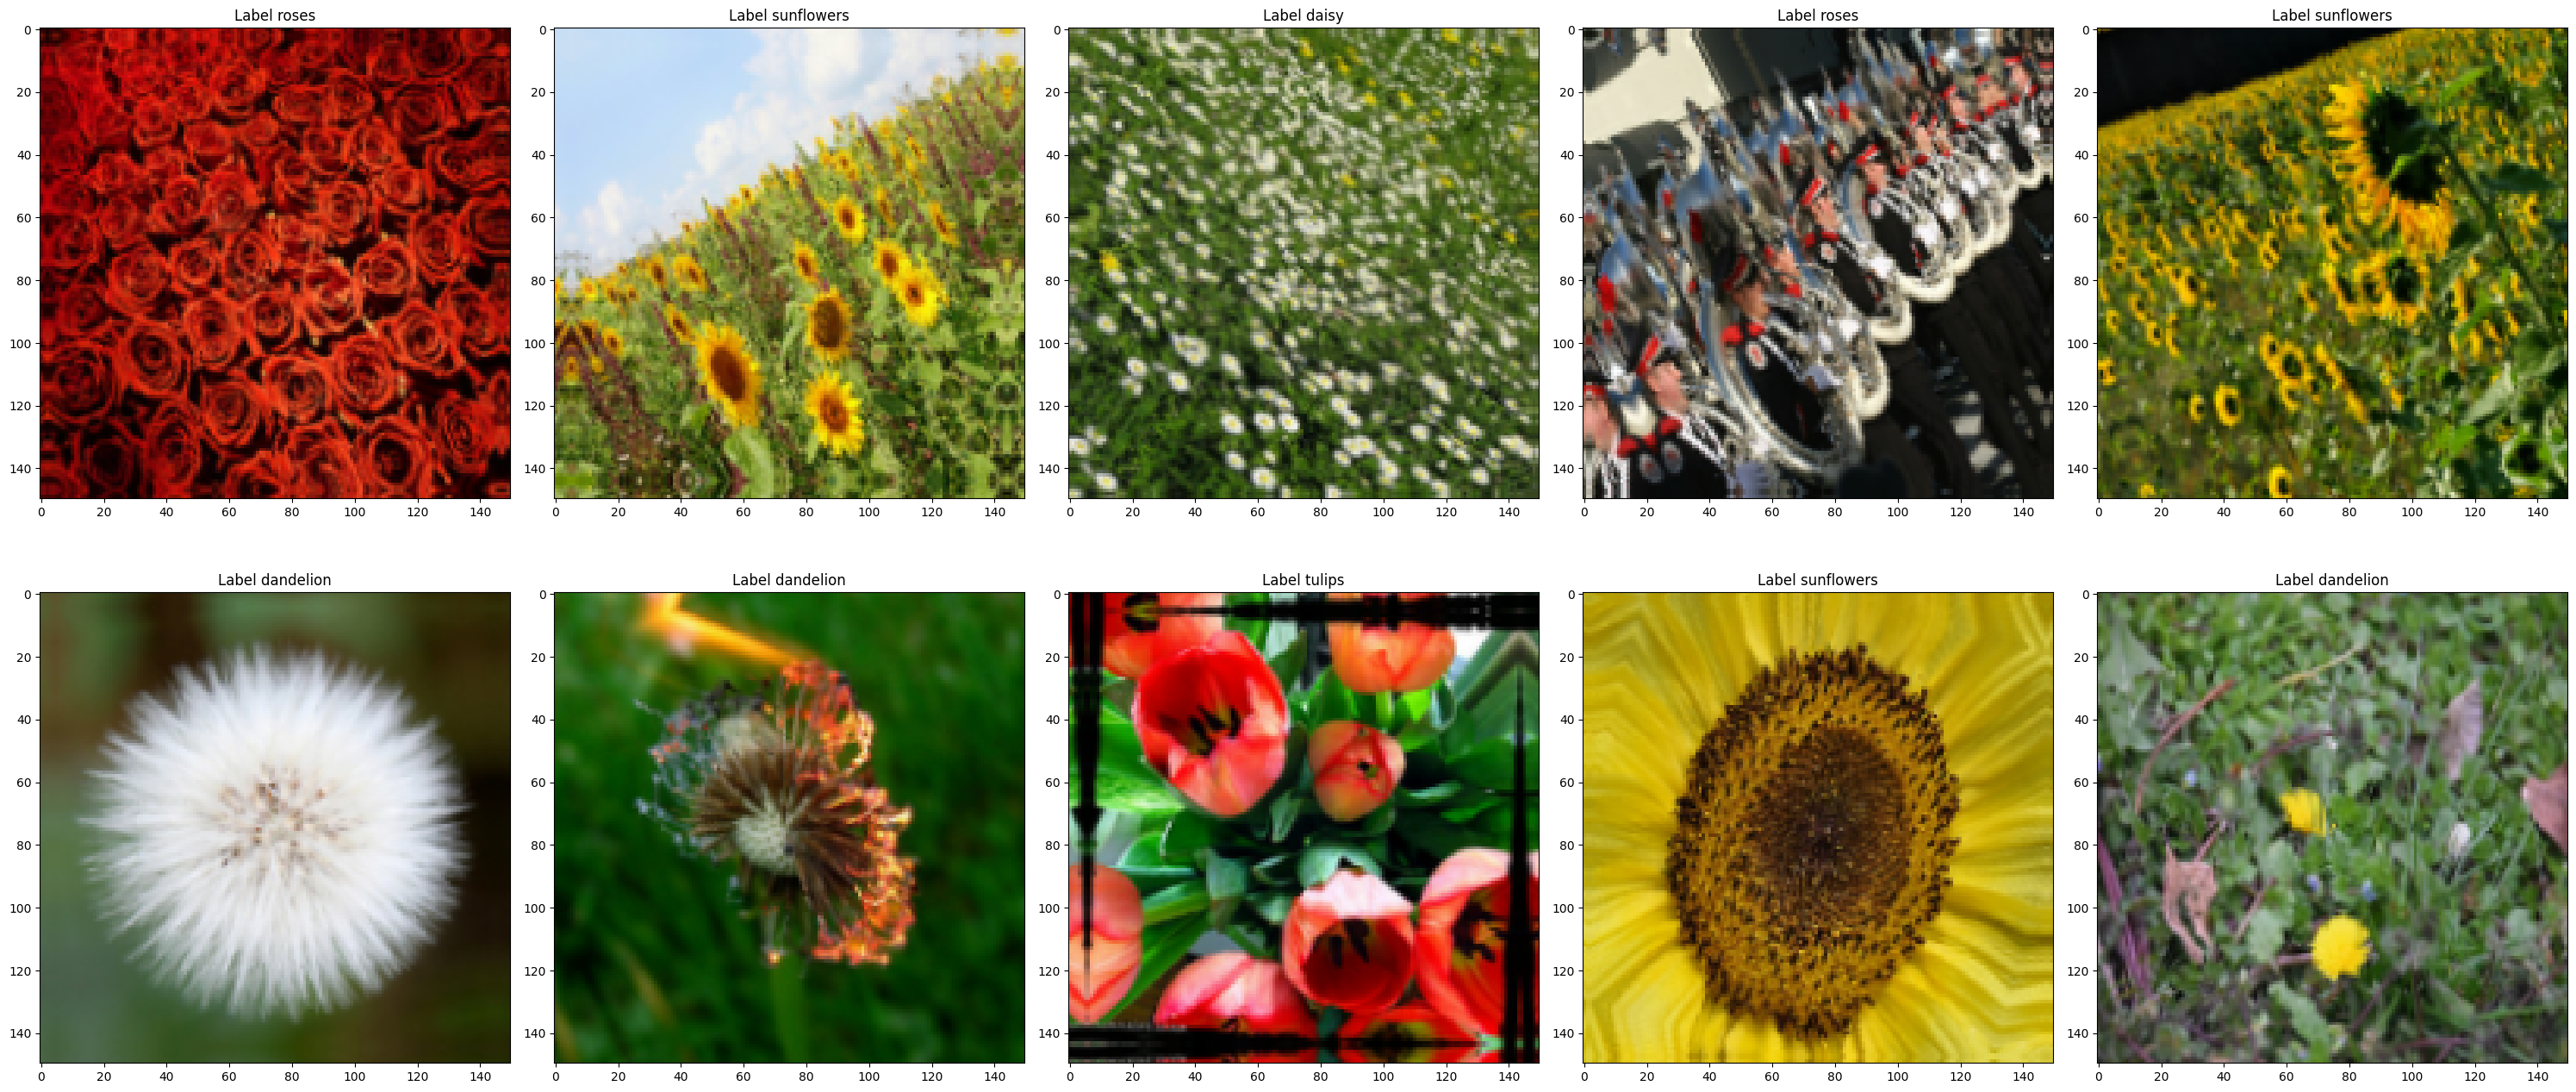

In [ ]:
plt.rcParams["figure.figsize"] = [30, 15]
plt.rcParams["figure.autolayout"] = True

counter = 0
for image, label in zip(train_images, train_labels):
  plt.subplot(2, 5, counter+1)
  data_augmentation(np.reshape(image, (1, HEIGHT, WIDTH, 3)))
  plt.imshow(data_augmentation(np.reshape(image, (1, HEIGHT, WIDTH, 3))).cpu().numpy().astype('uint8').squeeze())
  label_name = class_names[np.where(label==1)[0][0]]
  plt.title('Label {}'.format(label_name))
  counter += 1
  if counter == 10:
    break

In [ ]:
# help(layers.RandomRotation)

We will add data augmentation to your model before training in the next step.

In [ ]:
cnn_model_aug = Sequential([
  data_augmentation,
  layers.Rescaling(1./255),

  layers.Conv2D(16, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(32, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(64, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Conv2D(128, 3, padding='same', activation='relu'),
  layers.MaxPooling2D(),

  layers.Flatten(),
  layers.Dense(128, activation='relu'),

  layers.Dense(num_classes, name="outputs", activation='softmax')
])

In [ ]:
cnn_model_aug.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])

In [ ]:
%%time
epochs=50
history = cnn_model_aug.fit(
  train_images,
  train_labels,
  validation_split=0.2,
  epochs=epochs,
  batch_size=64,
  callbacks=[es]
)

Epoch 1/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 279ms/step - accuracy: 0.3603 - loss: 1.4356 - val_accuracy: 0.4558 - val_loss: 1.3115
Epoch 2/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.4885 - loss: 1.1833 - val_accuracy: 0.4694 - val_loss: 1.2624
Epoch 3/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 302ms/step - accuracy: 0.5716 - loss: 1.0515 - val_accuracy: 0.5612 - val_loss: 1.1236
Epoch 4/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 288ms/step - accuracy: 0.6086 - loss: 0.9803 - val_accuracy: 0.5425 - val_loss: 1.1665
Epoch 5/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 285ms/step - accuracy: 0.6256 - loss: 0.9509 - val_accuracy: 0.6190 - val_loss: 1.0450
Epoch 6/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 273ms/step - accuracy: 0.6572 - loss: 0.8890 - val_accuracy: 0.6361 - val_loss: 1.0266
Epoch 7/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 10s 268ms/step - accuracy: 0.6708 - loss: 0.8689 - val_accuracy: 0.5850 - val_loss: 1.0440
Epoch 8/50
37/37 ━━━━━━━━━━━━━━━━━━━━ 11s 286ms/step - accuracy: 0.6857 - loss: 0.8329 - val_accu

We observe that:
* training accuracy is ~.86
* validation accuracy is ~.70

In [ ]:
plt.rcParams["figure.figsize"] = [10, 5]
plt.rcParams["figure.autolayout"] = True

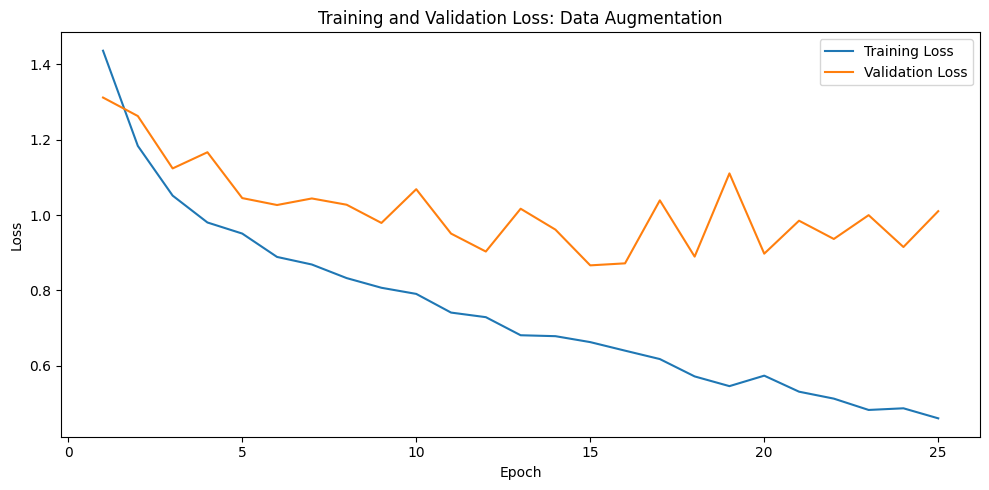

Text(0, 0.5, 'Accuracy')

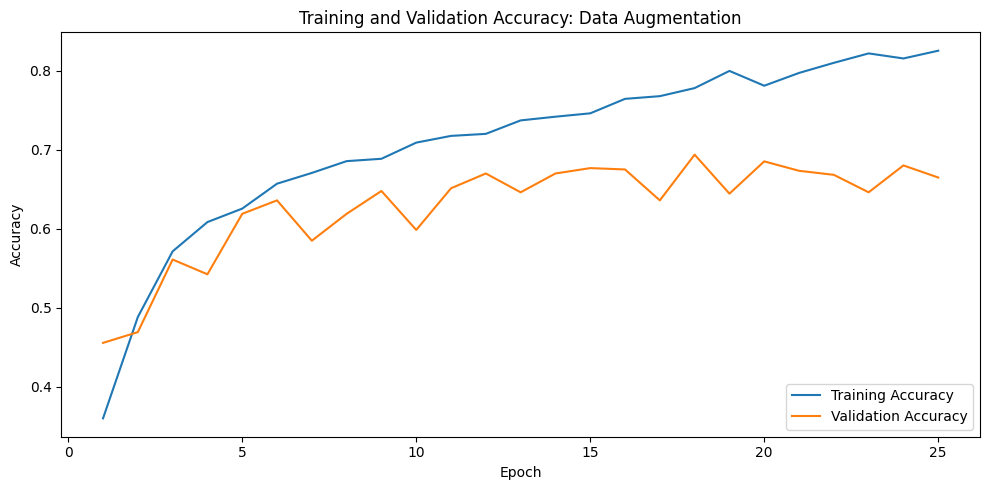

In [ ]:
# accuracy metrics at each iteration are stored in the history variable
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(1, len(history.history['loss'])+1)

# Loss
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss: Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.show()

# Accuracy
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy: Data Augmentation')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')

The gap between training and validation performance is smaller!

⚠️ **Warning!** When doing data augmentation make sure augmented derivatives from the same image do not appear both in your train and validation datasets!

🧑‍💻 **Exercise:** Change some of the random transformation parameters and check if there is difference in performance.

🧑‍💻 **Exercise:** What other data augmentation techniques can be useful for this problem? Check if they are provided in [Keras](https://keras.io/api/layers/preprocessing_layers/image_augmentation/).

## Model Testing

In [ ]:
# convert to numpy arrays
test_images, test_labels = zip(*list(test_ds.unbatch()))
test_images = np.array(test_images)
test_labels = np.array(test_labels)

In [ ]:
# dense model prediction
dense_model.evaluate(test_images, test_labels)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.4482 - loss: 1.2866


[1.286587119102478, 0.4482288956642151]

In [ ]:
# cnn model prediction
cnn_model.evaluate(test_images, test_labels)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step - accuracy: 0.6444 - loss: 0.8967


[0.8967247605323792, 0.6444141864776611]

In [ ]:
# run only if data augmentation section is run
# cnn_model_aug.evaluate(test_images, test_labels)

In [ ]:
# predict with a CNN model
from sklearn.metrics import ConfusionMatrixDisplay
pred_labels = cnn_model.predict(test_images)

23/23 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step


Text(0.5, 1.0, 'CNN Model')

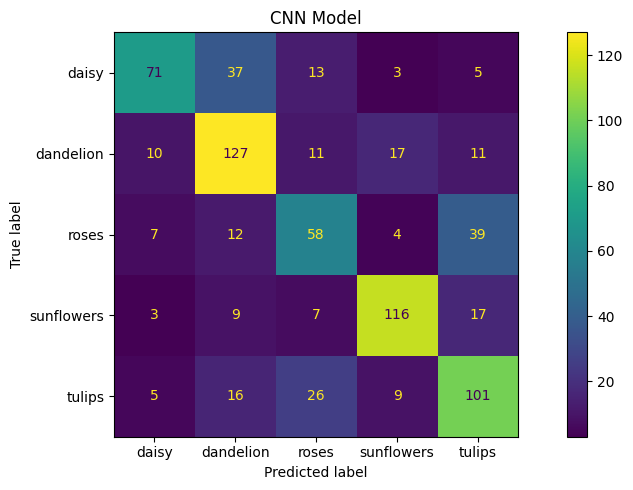

In [ ]:
disp = ConfusionMatrixDisplay.from_predictions(test_labels.argmax(axis=1),
                                               pred_labels.argmax(axis=1),
                                               display_labels=class_names,
                                               #normalize='pred',
                                               )
plt.title("CNN Model")

Go Out And Collect More Flower Photos!

# Recap

## Conceptual Takeaways

* Even simple dense neural networks for relatively small images have a huge number of parameters.
* Dense networks require flattening of the image which is not very meaningful for images of different sizes and with objects in different parts of the image. 2D CNNs address these problems.
* It is easy to overfit neural network models on small training datasets.
* Data augmentation helps building models robust to small variations in the data.

## Technical Takeaways
* Neural network libraries have a lot of tools to facilitate the data reading and preprocessing, however, sometimes they are doing steps under the hood that are not obvious.
* Identifying when to stop the training may not be trivial when the validation loss and accuracy are noisy.